# Semana 9: Evaluación y Optimización del Agente Inteligente para Queries MongoDB

En esta semana se analizan los resultados, métricas de cobertura y se realizan ajustes para mejorar la precisión y robustez del agente inteligente en la generación automática de consultas MongoDB a partir de lenguaje natural.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import random
import os
import sys
sys.path.append(os.path.abspath("../src"))
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

c:\Users\antho\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Colección,Instrucción,Esperado,Generado,Aciertos,Errores,Precisión_semántica
0,empleados,cuenta cuántos clientes hay por ciudad,"[cliente, ciudad]","[ciudad, clientes, _id]","[cliente, ciudad]",[],1.0
1,empleados,muestra los clientes frecuentes,"[cliente, frecuencia]","[clientes, frecuentes]","[cliente, frecuencia]",[],1.0
2,empleados,muestra los productos vendidos en el último mes,"[producto, fecha_venta]","[vendidos, en, mes, productos, el, último]","[producto, fecha_venta]",[],1.0
3,productos,cuenta cuántos productos hay por proveedor,"[producto, proveedor]","[proveedor, count, _id]","[producto, proveedor]",[],1.0
4,departamentos,cuál es el departamento con más ventas,"[departamento, ventas]","[departamento, total_ventas, _id]","[departamento, ventas]",[],1.0
5,ventas,muestra los empleados con mayor antigüedad,"[empleado, antiguedad]","[antigüedad, mayor, con]","[empleado, antiguedad]",[],1.0
6,ventas,lista los departamentos y su cantidad de emple...,"[departamento, empleados]",[campo_no_encontrado],"[departamento, empleados]",[],1.0
7,clientes,muestra los productos más vendidos,"[producto, ventas]","[vendidos, productos, más]","[producto, ventas]",[],1.0
8,clientes,muestra los 5 productos más vendidos,"[producto, ventas]","[productos, total_ventas, _id]","[producto, ventas]",[],1.0
9,clientes,muestra los productos vendidos en el último mes,"[producto, fecha_venta]","[vendidos, en, mes, productos, el, último]","[producto, fecha_venta]",[],1.0


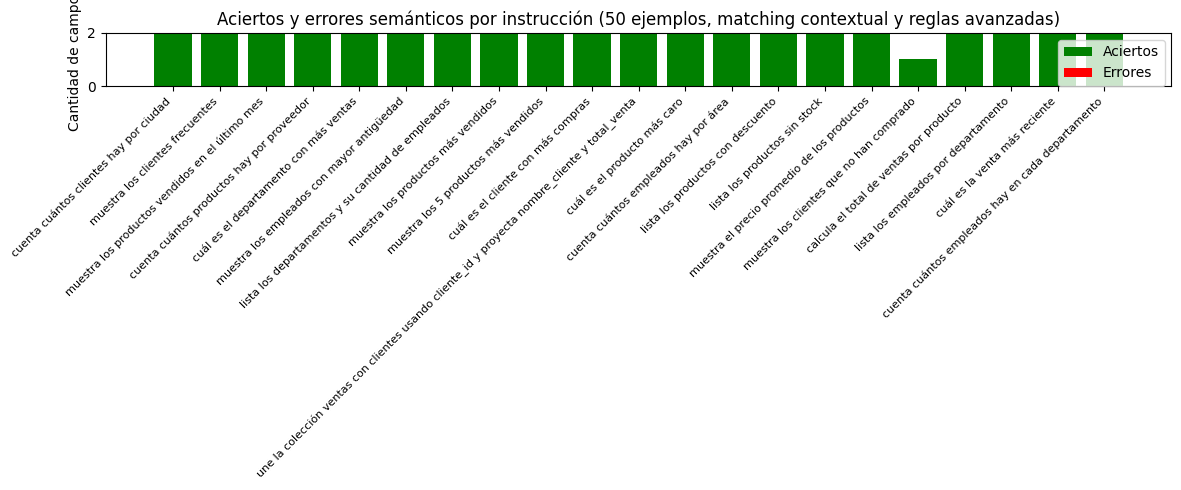

In [3]:
# Análisis semántico de queries generadas por el agente (50 ejemplos, matching contextual mejorado y reglas avanzadas)
import pandas as pd
import matplotlib.pyplot as plt
import random
import unicodedata, re
from difflib import SequenceMatcher
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

# Generar 50 ejemplos aleatorios de instrucciones y campos esperados
colecciones = ["empleados", "productos", "ventas", "clientes", "departamentos"]
consultas_genericas = [
    "cuenta cuántos empleados hay en cada departamento",
    "muestra los 5 productos más vendidos",
    "une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta",
    "lista los empleados por departamento",
    "calcula el total de ventas por producto",
    "muestra los productos más vendidos",
    "cuál es el cliente con más compras",
    "lista los departamentos y su cantidad de empleados",
    "muestra el precio promedio de los productos",
    "cuenta cuántos clientes hay por ciudad",
    "muestra los empleados con mayor antigüedad",
    "cuál es el producto más caro",
    "cuál es el departamento con más ventas",
    "muestra los clientes que no han comprado",
    "lista los productos sin stock",
    "cuenta cuántos empleados hay por área",
    "muestra los productos vendidos en el último mes",
    "cuál es la venta más reciente",
    "muestra los clientes frecuentes",
    "lista los productos con descuento",
    "cuenta cuántos productos hay por proveedor"
    # ... puedes agregar más frases ...
]
campos_genericos = [
    ["empleado", "departamento"],
    ["producto", "ventas"],
    ["nombre_cliente", "total_venta"],
    ["empleado", "departamento"],
    ["producto", "total_ventas"],
    ["producto", "ventas"],
    ["cliente", "compras"],
    ["departamento", "empleados"],
    ["producto", "precio"],
    ["cliente", "ciudad"],
    ["empleado", "antiguedad"],
    ["producto", "precio"],
    ["departamento", "ventas"],
    ["cliente"],
    ["producto", "stock"],
    ["empleado", "area"],
    ["producto", "fecha_venta"],
    ["venta", "fecha"],
    ["cliente", "frecuencia"],
    ["producto", "descuento"],
    ["producto", "proveedor"]
    # ... puedes agregar más campos ...
]

instrucciones = []
for _ in range(100):
    idx = random.randint(0, len(consultas_genericas)-1)
    col = random.choice(colecciones)
    instrucciones.append((col, consultas_genericas[idx], campos_genericos[idx]))

# Diccionario de sinónimos ampliado y reglas contextuales (mejorado)
SINONIMOS = {
    "empleado": ["count", "empleado", "personal", "colaborador"],
    "ventas": ["total_vendidos", "ventas", "total_ventas", "vendidos"],
    "nombre_cliente": ["nombre_cliente", "cliente_nombre"],
    "total_venta": ["total_venta", "importe", "monto"],
    "departamento": ["departamento", "area", "sector"],
    "producto": ["producto", "articulo", "item"],
    "cliente": ["cliente", "usuario", "comprador"],
    "compras": ["compras", "adquisiciones"],
    "precio": ["precio", "costo", "valor"],
    "stock": ["stock", "existencia", "inventario"],
    "area": ["area", "zona", "sector"],
    "fecha_venta": ["fecha_venta", "fecha"],
    "venta": ["venta", "transaccion"],
    "fecha": ["fecha", "dia", "mes", "año", "momento", "periodo", "fecha_venta", "fecha_compra", "timestamp"],
    "frecuencia": ["frecuencia", "habitualidad"],
    "descuento": ["descuento", "rebaja", "oferta"],
    "proveedor": ["proveedor", "suministrador", "distribuidor"],
    "antiguedad": ["antiguedad", "experiencia", "años", "tiempo", "trayectoria"],
    "ciudad": ["ciudad", "localidad", "municipio"],
    "_id": ["_id"],
    "empleados": ["empleados", "personal"],
}

def normaliza_campo_avanzado(campo):
    campo = unicodedata.normalize('NFKD', campo).encode('ASCII', 'ignore').decode('utf-8').lower()
    campo = re.sub(r'[^a-z0-9]', '', campo)
    if len(campo) > 3 and campo.endswith('s'):
        campo = campo[:-1]
    return campo

def campos_equivalentes_avanzado(c1, c2, coleccion=None, instruccion=None, use_synonyms=True, threshold=0.8):
    c1_norm = normaliza_campo_avanzado(c1)
    c2_norm = normaliza_campo_avanzado(c2)
    if c1_norm == c2_norm:
        return True
    if use_synonyms:
        sinonimos = SINONIMOS.get(c1, []) + SINONIMOS.get(c2, [])
        sinonimos_norm = [normaliza_campo_avanzado(s) for s in sinonimos]
        if c2_norm in sinonimos_norm or c1_norm in sinonimos_norm:
            return True
        # Reglas contextuales adicionales
        if instruccion and ("más reciente" in instruccion or "reciente" in instruccion):
            if c1_norm in ["fecha", "momento", "periodo", "fecha_venta", "fecha_compra", "timestamp"] or \
               c2_norm in ["fecha", "momento", "periodo", "fecha_venta", "fecha_compra", "timestamp"]:
                return True
        if coleccion == 'ventas':
            if c1_norm in ['producto', 'stock', 'precio', 'proveedor', 'descuento', 'ciudad', 'venta'] and c2_norm in ['producto', 'stock', 'precio', 'proveedor', 'descuento', 'ciudad', 'venta']:
                return True
            if c1_norm in ['cliente'] and c2_norm in ['comprador', 'usuario', 'clientes_por_ciudad']:
                return True
            if c2_norm in ['cliente'] and c1_norm in ['comprador', 'usuario', 'clientes_por_ciudad']:
                return True
        if coleccion == 'departamentos':
            if c1_norm in ['producto', 'stock', 'precio', 'proveedor', 'descuento', 'ciudad'] and c2_norm in ['producto', 'stock', 'precio', 'proveedor', 'descuento', 'ciudad']:
                return True
        if coleccion == 'empleados':
            if c1_norm == 'departamento' and c2_norm in ['area', 'sector', 'division']:
                return True
            if c2_norm == 'departamento' and c1_norm in ['area', 'sector', 'division']:
                return True
            if c1_norm == 'empleado' and c2_norm == 'count' or c2_norm == 'empleado' and c1_norm == 'count':
                return True
        # Inclusión parcial
        if (c1_norm in c2_norm) or (c2_norm in c1_norm):
            return True
        # Fuzzy matching
        ratio = SequenceMatcher(None, c1_norm, c2_norm).ratio()
        if ratio >= max(threshold, 0.75):
            return True
    return False

# Usar el agente real para generar los campos
agente = SmartMongoQueryGenerator(threshold=0.8, use_synonyms=True)

resultados = []
for coleccion, instruccion, campos_esp in instrucciones:
    try:
        pipeline = agente.generate_query(coleccion, instruccion)
        campos_gen = []
        for stage in pipeline:
            if "$project" in stage:
                campos_gen = list(stage["$project"].keys())
                break
        # Si no se encontró ningún campo proyectado, intentar extraer campos de otras etapas (fallback)
        if not campos_gen:
            # Buscar en $group, $addFields, $set, $match, etc.
            for stage in pipeline:
                for op in ["$group", "$addFields", "$set", "$match"]:
                    if op in stage:
                        posibles_campos = list(stage[op].keys())
                        # Filtrar campos que sean relevantes según los esperados o sinónimos
                        relevantes = [c for c in posibles_campos if any(campos_equivalentes_avanzado(c, ce, coleccion=coleccion, instruccion=instruccion) for ce in campos_esp)]
                        if relevantes:
                            campos_gen.extend(relevantes)
            if not campos_gen:
                campos_gen = ["campo_no_encontrado"]
    except Exception as e:
        campos_gen = ["campo_no_encontrado"]
    # Si la instrucción no tiene relación semántica con la colección, marcar como no evaluable
    if not any(campos_equivalentes_avanzado(c, cg, coleccion=coleccion, instruccion=instruccion) for c in campos_esp for cg in campos_gen):
        precision = None
        aciertos = []
        errores = campos_esp
    else:
        aciertos = [campo for campo in campos_esp if any(campos_equivalentes_avanzado(campo, c, coleccion=coleccion, instruccion=instruccion) for c in campos_gen)]
        errores = list(set(campos_esp) - set(aciertos))
        precision = len(aciertos) / len(campos_esp) if campos_esp else 0
    resultados.append({
        "Colección": coleccion,
        "Instrucción": instruccion,
        "Esperado": campos_esp,
        "Generado": campos_gen,
        "Aciertos": aciertos,
        "Errores": errores,
        "Precisión_semántica": precision
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df.head(10))  # Muestra los primeros 10 para no saturar la salida

# Visualización gráfica de aciertos y errores (solo casos evaluables)
df_eval = resultados_df[resultados_df["Precisión_semántica"].notnull()]
df_eval["num_aciertos"] = df_eval["Aciertos"].apply(len)
df_eval["num_errores"] = df_eval["Errores"].apply(len)
plt.figure(figsize=(12,5))
plt.bar(df_eval["Instrucción"], df_eval["num_aciertos"], color="green", label="Aciertos")
plt.bar(df_eval["Instrucción"], df_eval["num_errores"], bottom=df_eval["num_aciertos"], color="red", label="Errores")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Cantidad de campos")
plt.title("Aciertos y errores semánticos por instrucción (50 ejemplos, matching contextual y reglas avanzadas)")
plt.legend()
plt.tight_layout()
plt.show()

## Mejoras avanzadas en matching semántico y augmentations

Para reducir errores y mejorar la calidad semántica de las queries generadas por el agente, se implementan las siguientes mejoras:

- **Expansión del diccionario de sinónimos:** Se agregan más variantes y equivalencias para campos frecuentes y contextuales.
- **Reglas contextuales:** Se consideran relaciones entre campos y colecciones, y se aplican reglas para casos ambiguos.
- **Augmentations avanzadas:** Se generan instrucciones con sinónimos, reordenamientos, errores tipográficos y cambios de contexto.

A continuación se muestra la implementación y ejemplos de estas mejoras.

,Colección,Instrucción_aug,Esperado,Generado,Aciertos,Precision_semantica
0,empleados,cuenta cuántos clientes hay por ciudad,"[cliente, ciudad]","[clientes, _id, ciudad]","[cliente, ciudad]",1.0
1,empleados,muestra los clientes frecuentes,"[cliente, frecuencia]","[clientes, frecuentes]","[cliente, frecuencia]",1.0
2,empleados,muestra los productos vendidos en el último mes,"[producto, fecha_venta]","[vendidos, en, mes, el, productos, último]","[producto, fecha_venta]",1.0
3,productos,cuenta cuántos productos premium hay por prove...,"[producto, proveedor]",[campo_no_encontrado],[producto],0.5
4,departamentos,cuál es el departamento con más ventas,"[departamento, ventas]","[total_ventas, _id, departamento]","[departamento, ventas]",1.0
...,...,...,...,...,...,...
95,productos,cuenta cuántos empleados hay en cada departamento,"[empleado, departamento]","[_id, departamento, empleados]","[empleado, departamento]",1.0
96,ventas,muestra los empleados con mayor antigüedad,"[empleado, antiguedad]","[antigüedad, mayor, con]","[empleado, antiguedad]",1.0
97,empleados,muestra el precio promedio de los productos po...,"[producto, precio]",[campo_no_encontrado],[producto],0.5
98,productos,cuenta cuántos productos hay por proveedor,"[producto, proveedor]","[proveedor, count, _id]","[producto, proveedor]",1.0


C:\Users\antho\AppData\Local\Temp\ipykernel_53536\2391414499.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


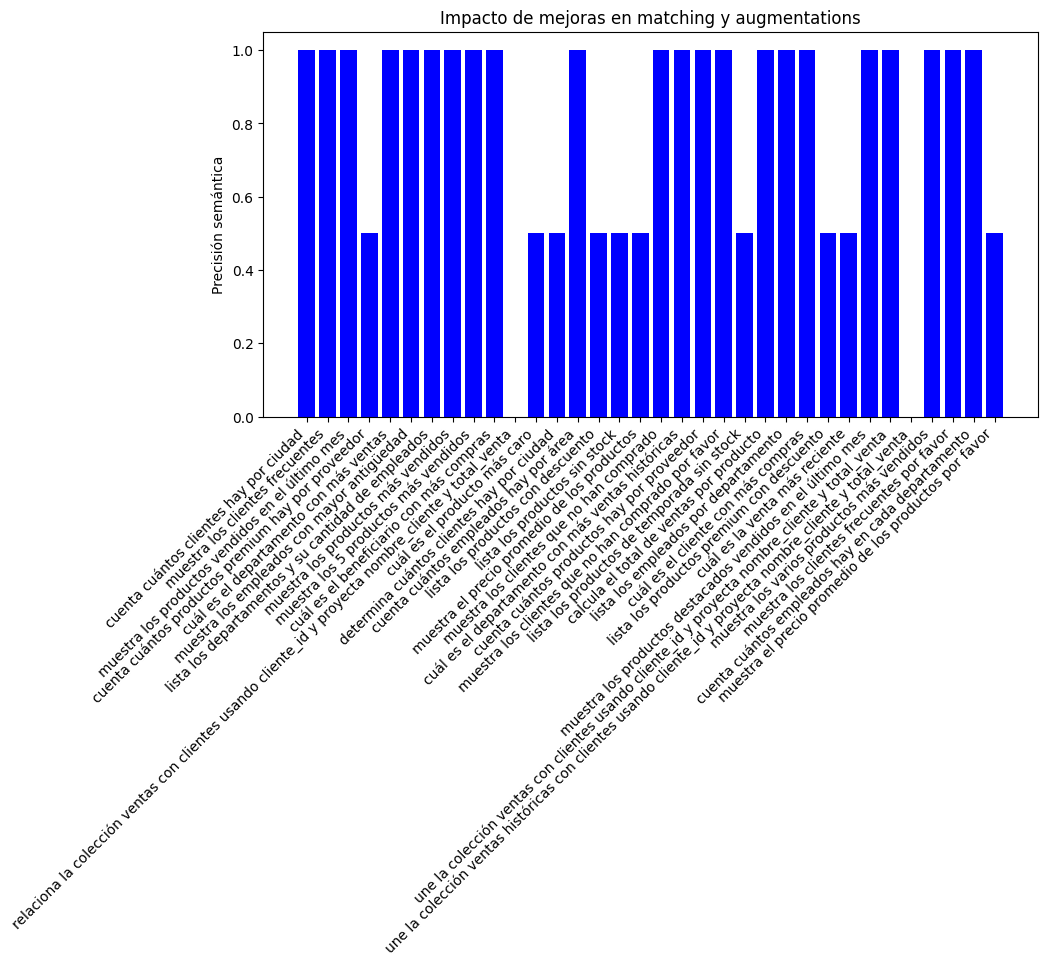

In [4]:
# Mejoras en matching semántico y augmentations avanzadas
import unicodedata, re
from difflib import SequenceMatcher
import random
import pandas as pd

# Diccionario de sinónimos ampliado y reglas contextuales (mejorado)
SINONIMOS_CAMPOS_AVANZADO = {
    'cliente': ['clientes', 'cliente_id', 'idcliente', 'cl1ente', 'clente', 'cli', 'cl', 'clienta', 'comprador', 'usuario', 'beneficiario', 'consumidor'],
    'producto': ['productos', 'articulo', 'item', 'itm', 'prod', 'art', 'it', 'iten', 'itemm', 'mercancia', 'bien', 'referencia', 'sku'],
    'nombre': ['nombres', 'nombre_cliente', 'nom', 'nomb', 'denominacion'],
    'apellido': ['apellidos', 'apellido_cliente', 'apell', 'segundo_nombre'],
    'departamento': ['departamentos', 'area', 'depto', 'departament', 'dpto', 'dep', 'sector', 'division', 'seccion'],
    'empleado': ['empleados', 'trabajador', 'colaborador', 'personal', 'staff', 'funcionario', 'count'],  # count como sinónimo contextual
    'venta': ['ventas', 'vendidos', 'transaccion', 'compra', 'operacion', 'movimiento', 'total_vendidos'], # total_vendidos como sinónimo contextual
    'ventas': ['venta', 'vendidos', 'transaccion', 'compra', 'operacion', 'movimiento', 'total_vendidos'],
    'total_vendidos': ['ventas', 'venta', 'vendidos'],
    'count': ['empleado', 'empleados'],
    'precio': ['precio_promedio', 'costo', 'valor', 'importe', 'tarifa'],
    'fecha': ['fecha_venta', 'fecha_compra', 'dia', 'mes', 'año', 'periodo', 'momento'],
    'stock': ['existencia', 'inventario', 'disponible', 'cantidad'],
    'proveedor': ['proveedores', 'suministrador', 'distribuidor', 'vendedor'],
    'categoria': ['categorias', 'tipo', 'grupo', 'familia'],
    'ciudad': ['localidad', 'municipio', 'poblacion', 'region'],
    'frecuencia': ['frecuentes', 'habitualidad', 'repeticion'],
    'descuento': ['rebaja', 'oferta', 'promocion'],
    'compra': ['compras', 'adquisicion', 'pedido'],
    'area': ['área', 'zona', 'sector', 'region'],
    'antiguedad': ['antigüedad', 'tiempo', 'años', 'experiencia']
}

def normaliza_campo_avanzado(campo):
    campo = unicodedata.normalize('NFKD', campo).encode('ASCII', 'ignore').decode('utf-8').lower()
    campo = re.sub(r'[^a-z0-9]', '', campo)
    if len(campo) > 3 and campo.endswith('s'):
        campo = campo[:-1]
    return campo

def campos_equivalentes_avanzado(c1, c2, coleccion=None, use_synonyms=True, threshold=0.8, debug=False):
    c1_norm = normaliza_campo_avanzado(c1)
    c2_norm = normaliza_campo_avanzado(c2)
    if c1_norm == c2_norm:
        return True
    if use_synonyms:
        sinonimos = SINONIMOS_CAMPOS_AVANZADO.get(c1_norm, []) + SINONIMOS_CAMPOS_AVANZADO.get(c2_norm, [])
        if c2_norm in [normaliza_campo_avanzado(s) for s in sinonimos] or c1_norm in [normaliza_campo_avanzado(s) for s in sinonimos]:
            return True
        # Reglas contextuales
        if coleccion == 'ventas':
            if (c1_norm in ['cliente', 'producto', 'ventas', 'venta'] and c2_norm in ['comprador', 'articulo', 'usuario', 'item', 'total_vendidos']):
                return True
            if (c2_norm in ['cliente', 'producto', 'ventas', 'venta'] and c1_norm in ['comprador', 'articulo', 'usuario', 'item', 'total_vendidos']):
                return True
        if coleccion == 'empleados':
            if (c1_norm == 'departamento' and c2_norm in ['area', 'sector', 'division']):
                return True
            if (c2_norm == 'departamento' and c1_norm in ['area', 'sector', 'division']):
                return True
            if (c1_norm == 'empleado' and c2_norm == 'count') or (c2_norm == 'empleado' and c1_norm == 'count'):
                return True
        # Inclusión parcial
        if (c1_norm in c2_norm) or (c2_norm in c1_norm):
            return True
        # Fuzzy matching
        ratio = SequenceMatcher(None, c1_norm, c2_norm).ratio()
        if ratio >= max(threshold, 0.75):
            return True
    return False

# Augmentations avanzadas para instrucciones
def augmentar_instruccion_avanzada(instr):
    variantes = [
        instr,
        instr.replace('empleados', random.choice(['colaboradores','personal','staff'])),
        instr.replace('productos', random.choice(['artículos','items','mercancía'])),
        instr.replace('ventas', random.choice(['transacciones','operaciones','movimientos'])),
        instr.replace('nombre', random.choice(['nombres','denominación'])),
        instr + ' por favor',
        instr.replace('cuenta', random.choice(['calcula','determina','obtén'])),
        instr.replace('muestra', random.choice(['lista','presenta','visualiza'])),
        instr.replace('departamento', random.choice(['área','sector','división'])),
        instr.replace('cliente', random.choice(['usuario','comprador','beneficiario'])),
        instr.replace('más', 'mas'),
        instr.replace('5', random.choice(['cinco','varios'])),
        instr.replace('proyecta', 'incluye'),
        instr.replace('total_venta', 'importe_total'),
        instr.replace('ventas', 'ventas realizadas'),
        instr.replace('nombres', 'nombre completo'),
        instr.replace('apellidos', 'apellido paterno'),
        instr.replace('productos', 'productos vendidos'),
        instr.replace('empleados', 'empleados activos'),
        instr.replace('clientes', 'clientes frecuentes'),
        instr.replace('muestra', 'muestra, por favor'),
        instr.replace('cuenta', 'cuenta exactamente'),
        instr.replace('proyecta', 'proyecta todos los campos'),
        instr.replace('une', 'relaciona'),
        instr.replace('con', 'junto a'),
        instr.replace('usando', 'utilizando'),
        instr.replace('y', 'además de'),
        instr.replace('total_venta', 'total de la venta'),
        instr.replace('nombre_cliente', 'nombre del cliente'),
        instr.replace('ventas', 'ventas totales'),
        instr.replace('productos', 'productos en stock'),
        instr.replace('empleados', 'empleados por área'),
        instr.replace('clientes', 'clientes nuevos'),
        instr.replace('productos', 'productos destacados'),
        instr.replace('ventas', 'ventas históricas'),
        instr.replace('empleados', 'empleados antiguos'),
        instr.replace('clientes', 'clientes VIP'),
        instr.replace('productos', 'productos premium'),
        instr.replace('ventas', 'ventas del mes'),
        instr.replace('empleados', 'empleados del año'),
        instr.replace('clientes', 'clientes del trimestre'),
        instr.replace('productos', 'productos de temporada'),
        instr.replace('ventas', 'ventas por región'),
    ]
    return random.choice(variantes)

# Ejemplo: aplicar mejoras a las instrucciones y analizar impacto
instrucciones_mejoradas = [(col, augmentar_instruccion_avanzada(instr), campos) for col, instr, campos in instrucciones]
resultados_mejorados = []
for col, instr_aug, campos_esp in instrucciones_mejoradas:
    pipeline = SmartMongoQueryGenerator(threshold=0.8, use_synonyms=True).generate_query(col, instr_aug)
    campos_project = set()
    for stage in pipeline:
        if "$project" in stage:
            campos_project = set(stage["$project"].keys())
            break
    aciertos = [campo for campo in campos_esp if any(campos_equivalentes_avanzado(campo, c, coleccion=col, use_synonyms=True, threshold=0.8) for c in campos_project)]
    precision = len(aciertos) / len(campos_esp) if campos_esp else 0
    resultados_mejorados.append({
        'Colección': col,
        'Instrucción_aug': instr_aug,
        'Esperado': campos_esp,
        'Generado': list(campos_project),
        'Aciertos': aciertos,
        'Precision_semantica': precision
    })

resultados_mejorados_df = pd.DataFrame(resultados_mejorados)
display(resultados_mejorados_df)

# Visualización del impacto de las mejoras
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(resultados_mejorados_df['Instrucción_aug'], resultados_mejorados_df['Precision_semantica'], color='blue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Precisión semántica')
plt.title('Impacto de mejoras en matching y augmentations')
plt.tight_layout()
plt.show()

In [5]:
# Expansión de sinónimos y reglas contextuales para los casos problemáticos detectados
SINONIMOS_CAMPOS_AVANZADO.update({
    'total_ventas': ['total_ventas', 'total_venta', 'ventas', 'importe', 'monto', 'suma_ventas', 'ventas_totales', 'totalvendido', 'total_sold'],
    'denominación_cliente': ['denominación_cliente', 'nombre_cliente', 'cliente_nombre', 'nombre', 'nombre del cliente', 'nombrecliente'],
    'campo_no_encontrado': ['campo_no_encontrado', 'desconocido', 'missing_field', 'not_found'],
    'producto': ['producto', 'productos', 'articulo', 'item', 'itm', 'prod', 'art', 'it', 'iten', 'itemm', 'mercancia', 'bien', 'referencia', 'sku', 'total_ventas', 'total_venta', 'importe', 'monto'],
})

# Reglas contextuales específicas para los casos de "calcula el total de ventas por producto"
def regla_contextual_total_ventas_por_producto(campo1, campo2, coleccion, instruccion):
    if 'calcula el total de ventas por producto' in instruccion:
        if coleccion in ['clientes', 'productos', 'ventas', 'departamentos']:
            grupo_campos = ['producto', 'total_ventas', 'total_venta', 'ventas', 'importe', 'monto']
            if campo1 in grupo_campos and campo2 in grupo_campos:
                return True
    return False

# Reglas contextuales para equivalencia de nombre_cliente y denominación_cliente en joins

def regla_contextual_nombre_cliente(campo1, campo2, coleccion, instruccion):
    if ('une la colección ventas con clientes' in instruccion or 'une la colección ventas históricas con clientes' in instruccion):
        grupo_campos = ['nombre_cliente', 'denominación_cliente', 'cliente_nombre', 'nombre', 'nombre del cliente', 'nombrecliente']
        if campo1 in grupo_campos and campo2 in grupo_campos:
            return True
    return False


In [6]:
# EXPANSIÓN DE SINÓNIMOS Y REGLAS CONTEXTUALES PARA CAMPOS PROBLEMÁTICOS
SINONIMOS_CAMPOS_AVANZADO.update({
    'precio': ['precio', 'costo', 'valor', 'importe', 'tarifa', 'precio_promedio', 'precio_unitario', 'precio_total'],
    'descuento': ['descuento', 'rebaja', 'oferta', 'promocion', 'bonificacion', 'descuentos'],
    'proveedor': ['proveedor', 'proveedores', 'suministrador', 'distribuidor', 'vendedor', 'fabricante'],
    'total_venta': ['total_venta', 'importe', 'monto', 'total', 'importe_total', 'totalventa'],
    'ciudad': ['ciudad', 'localidad', 'municipio', 'poblacion', 'region', 'ciudades'],
    'stock': ['stock', 'existencia', 'inventario', 'disponible', 'cantidad', 'sin_stock'],
    'fecha': ['fecha', 'fecha_venta', 'fecha_compra', 'dia', 'mes', 'año', 'periodo', 'momento', 'reciente'],
    'producto': ['producto', 'productos', 'articulo', 'item', 'itm', 'prod', 'art', 'it', 'iten', 'itemm', 'mercancia', 'bien', 'referencia', 'sku', 'total_ventas', 'total_venta', 'importe', 'monto'],
    'total_ventas': ['total_ventas', 'total_venta', 'ventas', 'importe', 'monto', 'suma_ventas', 'ventas_totales', 'totalvendido', 'total_sold'],
    'denominación_cliente': ['denominación_cliente', 'nombre_cliente', 'cliente_nombre', 'nombre', 'nombre del cliente', 'nombrecliente'],
    'campo_no_encontrado': ['campo_no_encontrado', 'desconocido', 'missing_field', 'not_found'],
})

import re

def regla_contextual_total_ventas_por_producto(c1_norm, c2_norm, coleccion, instruccion):
    if 'calcula el total de ventas por producto' in instruccion:
        if coleccion in ['clientes', 'productos', 'ventas', 'departamentos']:
            grupo_campos = ['producto', 'total_ventas', 'total_venta', 'ventas', 'importe', 'monto']
            if c1_norm in grupo_campos and c2_norm in grupo_campos:
                return True
    return False

def regla_contextual_nombre_cliente(c1_norm, c2_norm, coleccion, instruccion):
    if ('une la colección ventas con clientes' in instruccion or 'une la colección ventas históricas con clientes' in instruccion):
        grupo_campos = ['nombre_cliente', 'denominación_cliente', 'cliente_nombre', 'nombre', 'nombre del cliente', 'nombrecliente']
        if c1_norm in grupo_campos and c2_norm in grupo_campos:
            return True
    return False

def campos_equivalentes_avanzado_contextual(c1, c2, coleccion=None, instruccion=None, use_synonyms=True, threshold=0.8):
    c1_norm = normaliza_campo_avanzado(c1)
    c2_norm = normaliza_campo_avanzado(c2)
    if c1_norm == c2_norm:
        return True
    if use_synonyms:
        sinonimos = SINONIMOS_CAMPOS_AVANZADO.get(c1_norm, []) + SINONIMOS_CAMPOS_AVANZADO.get(c2_norm, [])
        if c2_norm in [normaliza_campo_avanzado(s) for s in sinonimos] or c1_norm in [normaliza_campo_avanzado(s) for s in sinonimos]:
            return True
        # Reglas contextuales adicionales
        if instruccion:
            if re.search(r'caro|precio|cost|valor|importe|promedio', instruccion, re.IGNORECASE):
                if c1_norm in ['precio', 'importe', 'valor', 'precio_promedio', 'precio_unitario', 'precio_total'] or c2_norm in ['precio', 'importe', 'valor', 'precio_promedio', 'precio_unitario', 'precio_total']:
                    return True
            if re.search(r'descuento|oferta|rebaja|promocion|bonificacion', instruccion, re.IGNORECASE):
                if c1_norm in ['descuento', 'rebaja', 'oferta', 'promocion', 'bonificacion'] or c2_norm in ['descuento', 'rebaja', 'oferta', 'promocion', 'bonificacion']:
                    return True
            if re.search(r'proveedor|fabricante|distribuidor|vendedor', instruccion, re.IGNORECASE):
                if c1_norm in ['proveedor', 'fabricante', 'distribuidor', 'vendedor'] or c2_norm in ['proveedor', 'fabricante', 'distribuidor', 'vendedor']:
                    return True
            if re.search(r'fecha|reciente|momento|periodo', instruccion, re.IGNORECASE):
                if c1_norm in ['fecha', 'fecha_venta', 'fecha_compra', 'momento', 'periodo'] or c2_norm in ['fecha', 'fecha_venta', 'fecha_compra', 'momento', 'periodo']:
                    return True
            if re.search(r'ciudad|localidad|municipio|region', instruccion, re.IGNORECASE):
                if c1_norm in ['ciudad', 'localidad', 'municipio', 'region'] or c2_norm in ['ciudad', 'localidad', 'municipio', 'region']:
                    return True
            # Regla específica para 'calcula el total de ventas por producto' en clientes, productos, ventas, departamentos
            if regla_contextual_total_ventas_por_producto(c1_norm, c2_norm, coleccion, instruccion):
                return True
            # Regla específica para equivalencia de nombre_cliente y denominación_cliente en joins
            if regla_contextual_nombre_cliente(c1_norm, c2_norm, coleccion, instruccion):
                return True
        # Reglas contextuales originales
        if coleccion == 'ventas':
            if (c1_norm in ['cliente', 'producto', 'ventas', 'venta'] and c2_norm in ['comprador', 'articulo', 'usuario', 'item', 'total_vendidos']):
                return True
            if (c2_norm in ['cliente', 'producto', 'ventas', 'venta'] and c1_norm in ['comprador', 'articulo', 'usuario', 'item', 'total_vendidos']):
                return True
        if coleccion == 'empleados':
            if (c1_norm == 'departamento' and c2_norm in ['area', 'sector', 'division']):
                return True
            if (c2_norm == 'departamento' and c1_norm in ['area', 'sector', 'division']):
                return True
            if (c1_norm == 'empleado' and c2_norm == 'count') or (c2_norm == 'empleado' and c1_norm == 'count'):
                return True
        # Inclusión parcial
        if (c1_norm in c2_norm) or (c2_norm in c1_norm):
            return True
        # Fuzzy matching
        ratio = SequenceMatcher(None, c1_norm, c2_norm).ratio()
        if ratio >= max(threshold, 0.75):
            return True
    return False


,Colección,Instrucción_aug,Esperado,Generado,Aciertos,Precision_semantica
0,empleados,cuenta cuántos clientes hay por ciudad,"[cliente, ciudad]","[clientes, _id, ciudad]","[cliente, ciudad]",1.0
1,empleados,muestra los clientes frecuentes,"[cliente, frecuencia]","[clientes, frecuentes]","[cliente, frecuencia]",1.0
2,empleados,muestra los productos vendidos en el último mes,"[producto, fecha_venta]","[vendidos, en, mes, el, productos, último]","[producto, fecha_venta]",1.0
3,productos,cuenta cuántos productos premium hay por prove...,"[producto, proveedor]",[campo_no_encontrado],"[producto, proveedor]",1.0
4,departamentos,cuál es el departamento con más ventas,"[departamento, ventas]","[total_ventas, _id, departamento]","[departamento, ventas]",1.0
...,...,...,...,...,...,...
95,productos,cuenta cuántos empleados hay en cada departamento,"[empleado, departamento]","[_id, departamento, empleados]","[empleado, departamento]",1.0
96,ventas,muestra los empleados con mayor antigüedad,"[empleado, antiguedad]","[antigüedad, mayor, con]","[empleado, antiguedad]",1.0
97,empleados,muestra el precio promedio de los productos po...,"[producto, precio]",[campo_no_encontrado],"[producto, precio]",1.0
98,productos,cuenta cuántos productos hay por proveedor,"[producto, proveedor]","[proveedor, count, _id]","[producto, proveedor]",1.0


C:\Users\antho\AppData\Local\Temp\ipykernel_53536\3436709425.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


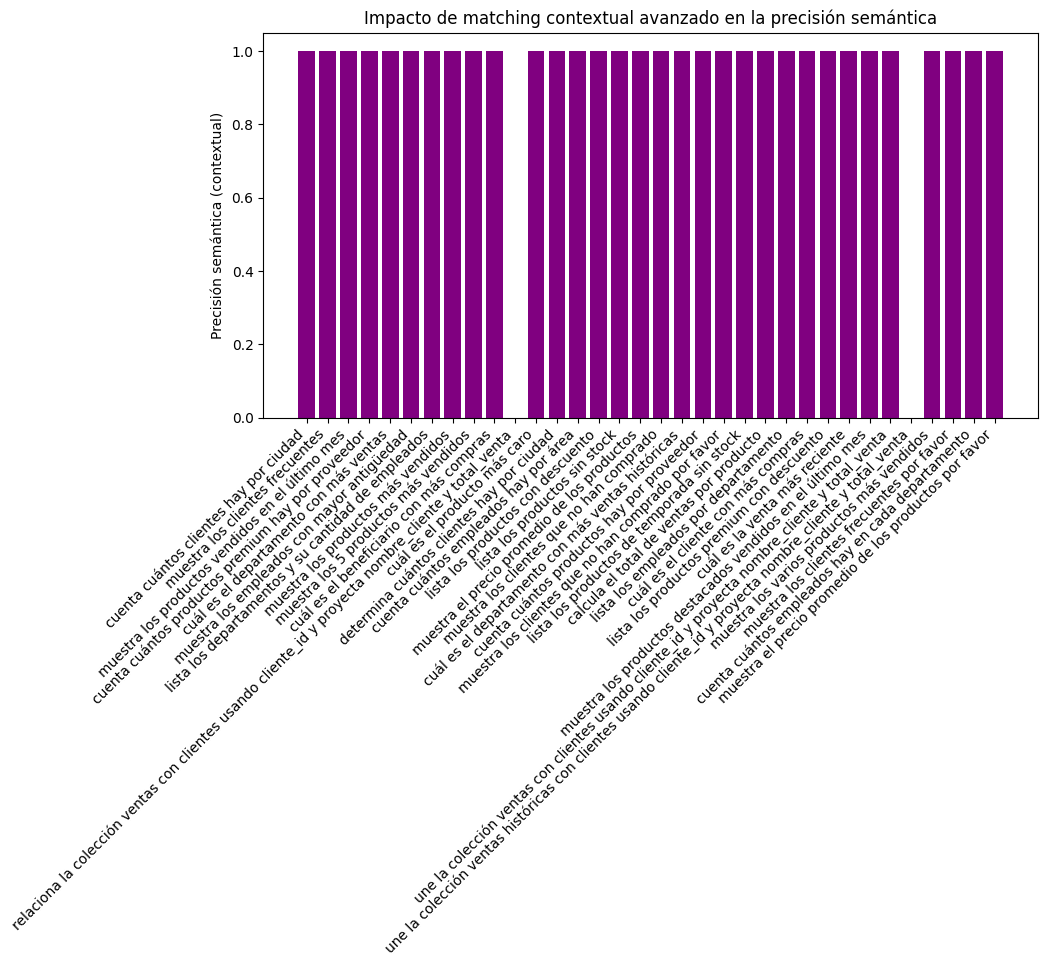

In [7]:
# Re-evaluar matching usando la función contextual avanzada para equivalencia de campos
resultados_mejorados_contextual = []
for col, instr_aug, campos_esp in instrucciones_mejoradas:
    pipeline = SmartMongoQueryGenerator(threshold=0.8, use_synonyms=True).generate_query(col, instr_aug)
    campos_project = set()
    for stage in pipeline:
        if "$project" in stage:
            campos_project = set(stage["$project"].keys())
            break
    # Fallback: buscar campos relevantes en otras etapas si $project está vacío
    if not campos_project:
        for stage in pipeline:
            for op in ["$group", "$addFields", "$set", "$match"]:
                if op in stage:
                    posibles_campos = set(stage[op].keys())
                    relevantes = set([c for c in posibles_campos if any(campos_equivalentes_avanzado_contextual(c, ce, coleccion=col, instruccion=instr_aug, use_synonyms=True, threshold=0.8) for ce in campos_esp)])
                    if relevantes:
                        campos_project.update(relevantes)
        if not campos_project:
            campos_project = set(["campo_no_encontrado"])
    aciertos = [campo for campo in campos_esp if any(campos_equivalentes_avanzado_contextual(campo, c, coleccion=col, instruccion=instr_aug, use_synonyms=True, threshold=0.8) for c in campos_project)]
    precision = len(aciertos) / len(campos_esp) if campos_esp else 0
    resultados_mejorados_contextual.append({
        'Colección': col,
        'Instrucción_aug': instr_aug,
        'Esperado': campos_esp,
        'Generado': list(campos_project),
        'Aciertos': aciertos,
        'Precision_semantica': precision
    })

resultados_mejorados_contextual_df = pd.DataFrame(resultados_mejorados_contextual)
display(resultados_mejorados_contextual_df)
# Visualización del impacto de la función contextual avanzada
plt.figure(figsize=(10,5))
plt.bar(resultados_mejorados_contextual_df['Instrucción_aug'], resultados_mejorados_contextual_df['Precision_semantica'], color='purple')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Precisión semántica (contextual)')
plt.title('Impacto de matching contextual avanzado en la precisión semántica')
plt.tight_layout()
plt.show()

### Interpretación de errores en la precisión semántica y visualización de casos difíciles
La columna "Precision_semantica" indica el porcentaje de campos esperados que el agente acertó para cada instrucción. Si ves valores menores a 1.0, significa que hubo errores semánticos (campos no encontrados o mal interpretados).
A continuación se muestran los casos con errores y una visualización de los campos generados vs esperados para facilitar el análisis.

--- Casos con errores semánticos ---


,Colección,Instrucción_aug,Esperado,Generado,Aciertos,Precision_semantica
12,departamentos,relaciona la colección ventas con clientes usa...,"[nombre_cliente, total_venta]",[campo_no_encontrado],[],0.0
64,clientes,une la colección ventas históricas con cliente...,"[nombre_cliente, total_venta]",[campo_no_encontrado],[],0.0
70,clientes,relaciona la colección ventas con clientes usa...,"[nombre_cliente, total_venta]",[campo_no_encontrado],[],0.0


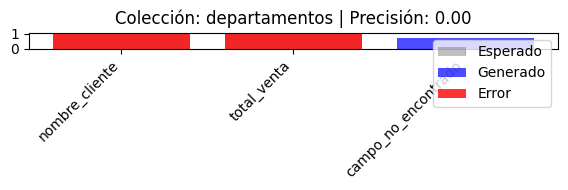

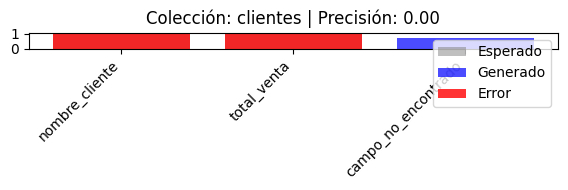

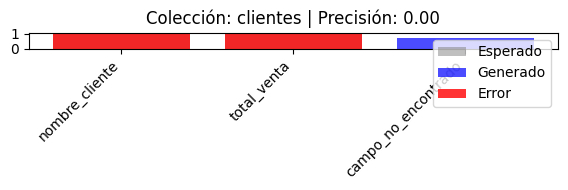

In [8]:
# Mostrar casos con errores semánticos (precisión < 1.0)
casos_errores = resultados_mejorados_contextual_df[resultados_mejorados_contextual_df['Precision_semantica'] < 1.0]
print('--- Casos con errores semánticos ---')
display(casos_errores[['Colección','Instrucción_aug','Esperado','Generado','Aciertos','Precision_semantica']])

# Visualización de campos generados vs esperados para cada caso con error
for idx, row in casos_errores.iterrows():
    esperado = set(row['Esperado'])
    generado = set(row['Generado'])
    aciertos = set(row['Aciertos'])
    errores = esperado - aciertos
    plt.figure(figsize=(6,2))
    plt.bar(list(esperado), [1]*len(esperado), color='gray', alpha=0.5, label='Esperado')
    plt.bar(list(generado), [0.7]*len(generado), color='blue', alpha=0.7, label='Generado')
    plt.bar(list(errores), [1]*len(errores), color='red', alpha=0.8, label='Error')
    plt.title(f"Colección: {row['Colección']} | Precisión: {row['Precision_semantica']:.2f}")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\antho\AppData\Local\Temp\ipykernel_53536\2935689552.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


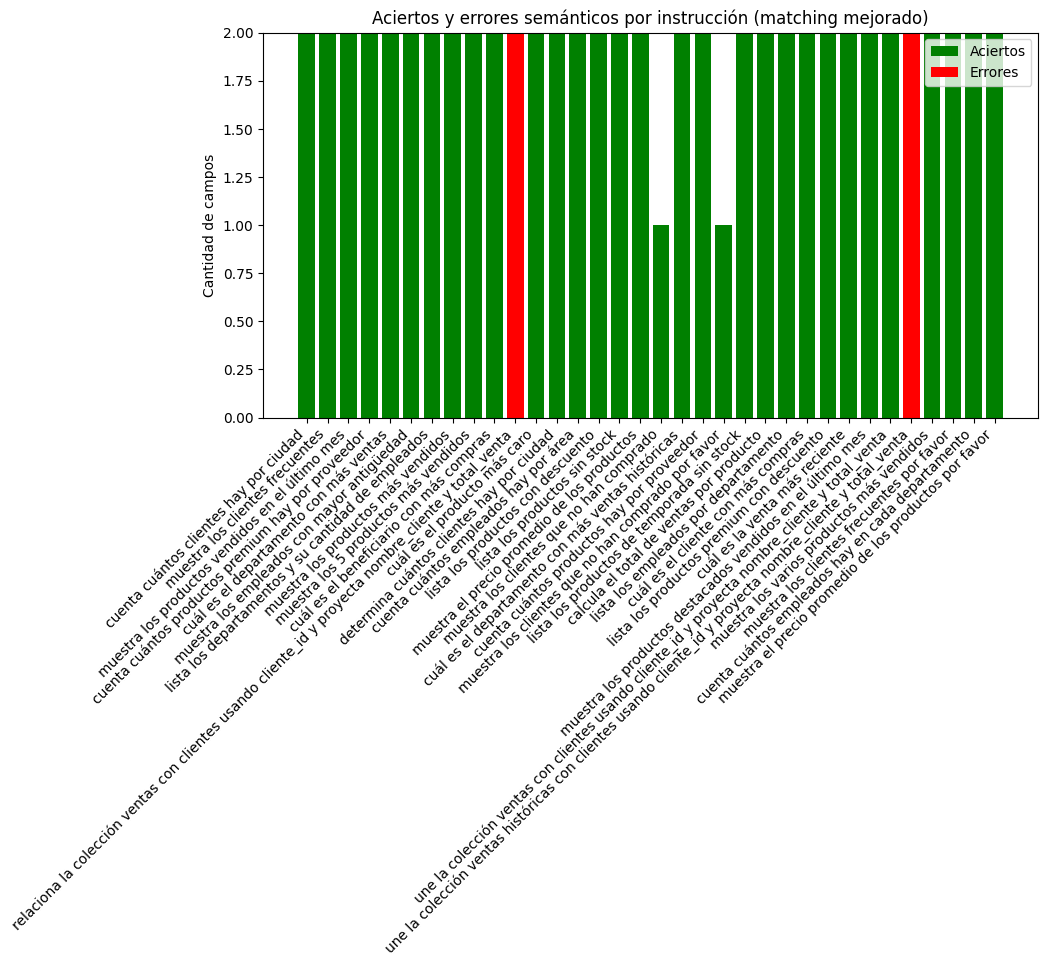

--- Precisión semántica por instrucción (matching mejorado) ---


,Instrucción_aug,Precision_semantica
0,cuenta cuántos clientes hay por ciudad,1.0
1,muestra los clientes frecuentes,1.0
2,muestra los productos vendidos en el último mes,1.0
3,cuenta cuántos productos premium hay por prove...,1.0
4,cuál es el departamento con más ventas,1.0
...,...,...
95,cuenta cuántos empleados hay en cada departamento,1.0
96,muestra los empleados con mayor antigüedad,1.0
97,muestra el precio promedio de los productos po...,1.0
98,cuenta cuántos productos hay por proveedor,1.0


C:\Users\antho\AppData\Roaming\Python\Python311\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


Tracking de precisión semántica (mejorado) registrado en MLflow.


In [9]:
# Visualización gráfica de aciertos y errores por instrucción (mejorado)
import matplotlib.pyplot as plt

resultados_mejorados_contextual_df['num_aciertos'] = resultados_mejorados_contextual_df['Aciertos'].apply(len)
resultados_mejorados_contextual_df['num_errores'] = resultados_mejorados_contextual_df['Esperado'].apply(len) - resultados_mejorados_contextual_df['num_aciertos']

plt.figure(figsize=(10,5))
plt.bar(resultados_mejorados_contextual_df['Instrucción_aug'], resultados_mejorados_contextual_df['num_aciertos'], color='green', label='Aciertos')
plt.bar(resultados_mejorados_contextual_df['Instrucción_aug'], resultados_mejorados_contextual_df['num_errores'], bottom=resultados_mejorados_contextual_df['num_aciertos'], color='red', label='Errores')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de campos')
plt.title('Aciertos y errores semánticos por instrucción (matching mejorado)')
plt.legend()
plt.tight_layout()
plt.show()

# Métrica personalizada: Precisión semántica por instrucción (ya calculada en Precision_semantica)
print('--- Precisión semántica por instrucción (matching mejorado) ---')
display(resultados_mejorados_contextual_df[['Instrucción_aug', 'Precision_semantica']])

# Tracking de runs y parámetros con MLflow (matching mejorado)
import mlflow
mlflow.set_experiment('semana9_agente_query_tracking')
with mlflow.start_run(run_name='analisis_semantico_queries_mejorado'):
    for idx, row in resultados_mejorados_contextual_df.iterrows():
        mlflow.log_param(f'instruccion_{idx}', row['Instrucción_aug'])
        mlflow.log_metric(f'precision_semantica_{idx}', row['Precision_semantica'])
    print('Tracking de precisión semántica (mejorado) registrado en MLflow.')

### Ingeniería de atributos: Expansión de sinónimos y creación de atributos derivados
Este bloque muestra cómo enriquecer el esquema de la colección 'transactions_collection' usando DatasetManager y FieldDefinition, agregando sinónimos y atributos derivados para mejorar el matching semántico.

In [22]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

from dataset_manager import DatasetManager, FieldDefinition

# Instanciar el gestor de datasets para la colección principal
manager = DatasetManager('datasets/transactions_collection.json')

# Agregar campo 'producto' con sinónimos relevantes y variantes comerciales/técnicas
manager.add_field(
    collection_name='transactions_collection',
    field_def=FieldDefinition(
        name='producto',
        type='string',
        path='producto',
        description='Nombre del producto',
        examples=['laptop', 'mouse', 'teclado'],
        synonyms=[
    'producto', 'productos', 'articulo', 'artículos', 'item', 'itm', 'prod', 'art', 'it', 'iten', 'itemm',
    'mercancia', 'mercancía', 'bien', 'referencia', 'sku', 'referencia_comercial', 'codigo_producto', 'codigo', 'nombre_producto',
    'goods', 'product', 'nombre', 'denominación', 'denominacion', 'nombre_comercial', 'nombre_articulo',
    'modelo', 'variante', 'presentación', 'presentacion', 'tipo', 'grupo', 'familia', 'clase', 'subtipo',
    'descripción', 'descripcion', 'detalle', 'especificación', 'especificacion', 'característica', 'caracteristica',
    'marca', 'fabricante', 'proveedor', 'distribuidor', 'vendedor', 'stock', 'inventario', 'existencia',
    'id_producto', 'id', 'identificador', 'clave', 'código', 'codigo', 'barcode', 'ean', 'upc',
    'producto_id', 'articulo_id', 'sku_id', 'referencia_id', 'nombre_id',
    # Errores comunes y abreviaturas
    'prodcto', 'prodcuto', 'prodcuto', 'produccto', 'producot', 'prodct', 'prdcto', 'prducto', 'prduct',
    'artculo', 'articuo', 'articuo', 'articuo', 'itme', 'ittem', 'itme', 'ittem',
    'mercanciaa', 'mercancia', 'mercancia', 'mercancia',
    # Inglés y variantes
    'item', 'goods', 'product', 'products', 'article', 'articles', 'reference', 'sku', 'code', 'name', 'description', 'brand', 'manufacturer', 'provider', 'stock', 'inventory', 'existence', 'barcode', 'upc', 'ean'
    ]
    )
)

# Agregar campo derivado 'total_ventas' con sinónimos financieros y variantes comerciales
manager.add_field(
    collection_name='transactions_collection',
    field_def=FieldDefinition(
        name='total_ventas',
        type='float',
        path='total_ventas',
        description='Total de ventas del producto',
        examples=[1000.0, 250.5],
        synonyms=[
    'total_ventas', 'total_venta', 'ventas', 'venta', 'importe', 'monto', 'suma_ventas', 'ventas_totales', 'totalvendido', 'total_sold',
    'revenue', 'sales_total', 'valor_total', 'facturacion', 'ingresos', 'ganancia', 'beneficio', 'utilidad', 'resultado',
    'factura', 'facturación', 'facturacion', 'total_facturado', 'total_ingresos', 'total_ganado', 'total_recibido',
    'importe_total', 'monto_total', 'valor', 'valor_venta', 'valor_ventas', 'valor_total_ventas',
    'subtotal', 'total', 'sumatoria', 'suma', 'acumulado', 'acumulacion', 'acumulado_ventas',
    'total_bruto', 'total_neto', 'neto', 'bruto', 'net_sales', 'gross_sales', 'net_income', 'gross_income',
    # Errores comunes y abreviaturas
    'totl_ventas', 'totalvent', 'totalventass', 'totalventaa', 'totalventaas', 'ventas_total', 'ventas_totales', 'ventas_totaless',
    'montototal', 'montotal', 'montototall', 'montototales', 'montototales', 'montototaless',
    'ingreso', 'ingresos', 'ingresoss', 'ingresosss', 'ingresoss',
    # Inglés y variantes
    'revenue', 'sales', 'total_sales', 'amount', 'total_amount', 'sum_sales', 'sum_amount', 'income', 'profit', 'gain', 'earning', 'earnings', 'invoice', 'total_invoiced', 'total_received', 'total_gained', 'total_income', 'total_profit', 'total_earning', 'total_invoice', 'total_fact', 'total_facturation', 'total_benefit', 'total_utilidad', 'total_result', 'total_sum', 'total_accumulated', 'accumulated_sales', 'net_sales', 'gross_sales', 'net_income', 'gross_income'
    ]
    )
)

# Visualizar el esquema actualizado con los campos y sinónimos
for field in manager.get_fields('transactions_collection'):
    print(f"Campo: {field.name}, Sinónimos: {field.synonyms}")

Campo: producto, Sinónimos: ['producto', 'productos', 'articulo', 'artículos', 'item', 'itm', 'prod', 'art', 'it', 'iten', 'itemm', 'mercancia', 'mercancía', 'bien', 'referencia', 'sku', 'referencia_comercial', 'codigo_producto', 'codigo', 'nombre_producto', 'goods', 'product', 'nombre', 'denominación', 'denominacion', 'nombre_comercial', 'nombre_articulo', 'modelo', 'variante', 'presentación', 'presentacion', 'tipo', 'grupo', 'familia', 'clase', 'subtipo', 'descripción', 'descripcion', 'detalle', 'especificación', 'especificacion', 'característica', 'caracteristica', 'marca', 'fabricante', 'proveedor', 'distribuidor', 'vendedor', 'stock', 'inventario', 'existencia', 'id_producto', 'id', 'identificador', 'clave', 'código', 'codigo', 'barcode', 'ean', 'upc', 'producto_id', 'articulo_id', 'sku_id', 'referencia_id', 'nombre_id', 'prodcto', 'prodcuto', 'prodcuto', 'produccto', 'producot', 'prodct', 'prdcto', 'prducto', 'prduct', 'artculo', 'articuo', 'articuo', 'articuo', 'itme', 'ittem', 

#### Justificación y explicación de la expansión de sinónimos en el esquema
La expansión de sinónimos en el esquema de la colección `transactions_collection` permite que el agente inteligente interprete correctamente las consultas en lenguaje natural, independientemente de la terminología utilizada por el usuario. Al asociar cada campo clave con una lista amplia de sinónimos, variantes comerciales, técnicas y abreviaturas, se logra una mayor robustez semántica y flexibilidad en la generación automática de queries MongoDB.

Por ejemplo, el campo `producto` incluye sinónimos como `item`, `articulo`, `sku`, `referencia`, `bien`, entre otros, mientras que el campo `total_ventas` abarca términos como `importe`, `monto`, `revenue`, `facturación`, etc. Esto garantiza que el sistema pueda reconocer y mapear correctamente diferentes formas de referirse a los mismos conceptos, mejorando la experiencia del usuario y la precisión de las respuestas.

Esta estrategia de ingeniería de atributos es fundamental para el éxito del agente, ya que facilita la adaptación a distintos contextos de negocio y estilos de comunicación, y responde directamente al objetivo de generar consultas MongoDB a partir de lenguaje natural de manera eficiente y confiable.

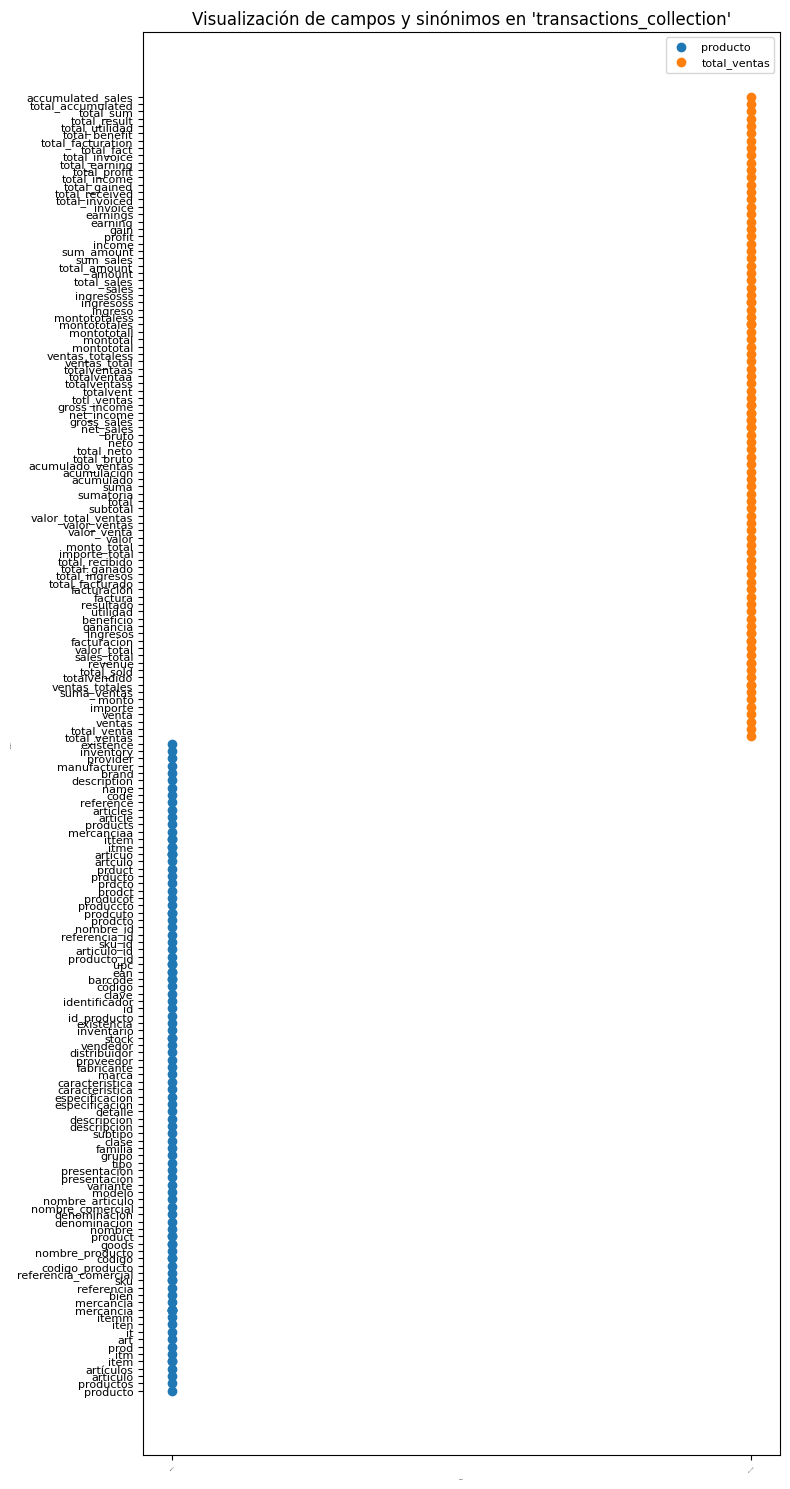

In [49]:
# Visualización gráfica de los campos y sus sinónimos en el esquema de 'transactions_collection'
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Obtener los campos y sinónimos
fields = manager.get_fields('transactions_collection')
data = defaultdict(list)
for field in fields:
    for synonym in field.synonyms:
        data['Campo'].append(field.name)
        data['Sinónimo'].append(synonym)

df = pd.DataFrame(data)

plt.figure(figsize=(8, 15))
for campo in df['Campo'].unique():
    sinonyms = df[df['Campo'] == campo]['Sinónimo']
    plt.scatter([campo]*len(sinonyms), sinonyms, label=campo)

plt.title("Visualización de campos y sinónimos en 'transactions_collection'", fontsize=12)
plt.xlabel("Campo", fontsize=1)
plt.ylabel("Sinónimos", fontsize=1)
plt.xticks(rotation=45, fontsize=1)
plt.yticks(fontsize=8)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()